# Inflection-based Elevations from Channel Topography (INFLECT)

INFLECT is a Python tool for identifying persistent topographic features of river corridors, such as channel banks and floodplain terraces, using topography as the only input data source. INFLECT uses cross-sections derived from a digital elevation model (DEM) to identify inflections in cross-section width, which are indicative of topographic features. Inputs to INFLECT are a DEM, a river thalweg/centerline, and a set of transects spanning the study reach. Outputs include a series of diagnostic figures described below, a set of elevations representing major topographic feature locations on the study reach, and a shapefile of topographic feature locations along the input transects. The steps of the INFLECT process are summarized in the figure below:

<img src="images/Methods_fig.png" width="800">

## Setting up the environment

In [15]:
import os
import glob
import geopandas as gpd
import pandas as pd
import glob
import rasterio
from rasterio import features
import ast
from shapely.geometry import Point, shape, MultiPoint
from shapely.geometry.point import Point
from shapely.ops import unary_union
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime
import sys
import time
from analysis import calc_dwdh, inflect, get_raster_boundary
from visualization import output_record, plot_bankfull_increments, plot_longitudinal_profile, transect_plot, plot_inflections
from spatial_analysis import create_bankfull_pts

This section of code sets algorithm parameters for INFLECT. These include project units (which should align with the units in the dem), the interval of width measurements along the channel elevation (Step 2, figure above), the method of calculating cross-section width (counting discontinuous sections of width, or continuous segments only), and various parameters used in the peak detection function (Step 5, figure above). Different river corridor settings and sizes may work best with different combinations of parameters, but default values are expected to perform well for a wide variety of settings. 

In [2]:
# Set INFLECT algorithm parameters
units = 'meters' # based on units in DEM
sampling_interval = 1 # set elevation sampling interval along transect in units of meters
d_interval = 10/100 # Set intervals to step up in cross-section depth. Default is units meters and 1/10m intervals
slope_window = 10 # Set window size for calculating slope for derivatives. Set in d_interval units. 
lower_bound = 5 # Set lower vertical boundary for inflection id within cross-section, in units of d_interval. Default 5 = 50cm
upper_bound = 100 # Set upper vertical boundary for inflection id within cross-section, in units of d_interval. Default 100 = 10m
spatial_plot_interval = 0.5 # interval to measure elevations along transects, default units meters.
width_calc_method = 'partial' # 'continuous' 'partial' - choose from either partial additive widths or continuous-only methods of width calculation.
# peak detection parameters
inflect_calc_method = 'cross-section' # 'cross-section' or 'aggregate' method for inflection calculation. 'cross-section' is default. 
max_peak_ratio = 3 # The ratio of max peak:detected peak. Default val 2 means the detected peak must be one half the magnitude of the maximum peak. 
distance_val = 1 # The minimum distance required between individual peaks, unitless. Must be greater or equal to 1. 
width_val = .1 # The minumum width of an individual peak at the base, unitless
prominence_val = .1 # optional, the prominence required for an individual peak, unitless
bankfull = 'yes' # *In development*. 'yes' or 'no', whether to return a bankfull estimate only (yes) or return all major inflections

### Prepare data inputs and data output folders:

In [3]:
# Specify input data file paths in correct input folder directories
reach_name = 'Kentucky'
dem_fp = 'data_inputs/Kentucky/dem/dem.tif'
thalweg_fp = 'data_inputs/Kentucky/centerline/TW.shp'
cross_section_fp = 'data_inputs/Kentucky/cross-sections/TW_xs.shp'

# Create output folders if needed, delete old files in output folders if they exist.
if not os.path.exists('data_outputs/{}'.format(reach_name)):
    os.makedirs('data_outputs/{}'.format(reach_name))
if not os.path.exists('data_outputs/{}/transect_plots'.format(reach_name)):
    os.makedirs('data_outputs/{}/transect_plots'.format(reach_name))
else:
    files = glob.glob('data_outputs/{}/transect_plots/*'.format(reach_name))
    for f in files:
        os.remove(f)
if not os.path.exists('data_outputs/{}/second_order_roc'.format(reach_name)):
    os.makedirs('data_outputs/{}/second_order_roc'.format(reach_name))
else:
    files = glob.glob('data_outputs/{}/second_order_roc/*'.format(reach_name))
    for f in files:
        os.remove(f)
if not os.path.exists('data_outputs/{}/all_widths'.format(reach_name)):
    os.makedirs('data_outputs/{}/all_widths'.format(reach_name))
else:        
    files = glob.glob('data_outputs/{}/all_widths/*'.format(reach_name))  
    for f in files:
        os.remove(f)  
if not os.path.exists('data_outputs/{}/spatial'.format(reach_name)):
    os.makedirs('data_outputs/{}/spatial'.format(reach_name))

### Running INFLECT

The first step is to measure widths in incremental units up the cross-section profile. In this step, the input dem is sampled in a spaced interval across each cross-section, and the resulting profile is measured for width. This step uses the ```calc_width``` function from the ```Analysis.py``` file. 

In [4]:
print('Running INFLECT for station: {}'.format(reach_name))
# Read in data: thalweg, and cross-sections 
cross_sections = gpd.read_file(cross_section_fp)
thalweg = gpd.read_file(thalweg_fp)

all_widths_df = calc_dwdh(reach_name, cross_sections, dem_fp, sampling_interval, d_interval, width_calc_method) # calc widths array for each cross-section
print('Width calcs done!')

Running INFLECT for station: Kentucky
Width calcs done!


Next, the cross-section widths calculated in the previous step are used to calculate major inflection points across the river reach. This function takes a number of user-defined inputs (or defaults), including the method used for aggregating cross-sections in inflect. 

In [10]:
inflect(reach_name, inflect_calc_method, d_interval, all_widths_df, slope_window, max_peak_ratio, distance_val, width_val, prominence_val)

An output record is also generated to track the user parameters associated with this run of INFLECT. The output record is saved to the outputs folder for the reach. 

In [14]:
output_record(reach_name, slope_window, d_interval, sampling_interval, width_calc_method, units)

TypeError: output_record() missing 1 required positional argument: 'execution_time_minutes'

### Visualizing the outputs
Now a series of plots are generated to visualize the outputs from INFLECT. These can help with interpretation of the results or as a diagnostic tool if tuning the INFLECT input parameters. Functions called here are sourced from the ```Visualization.py``` file. Plots are saved to the outputs folder for the reach. 

Generating visualizations...


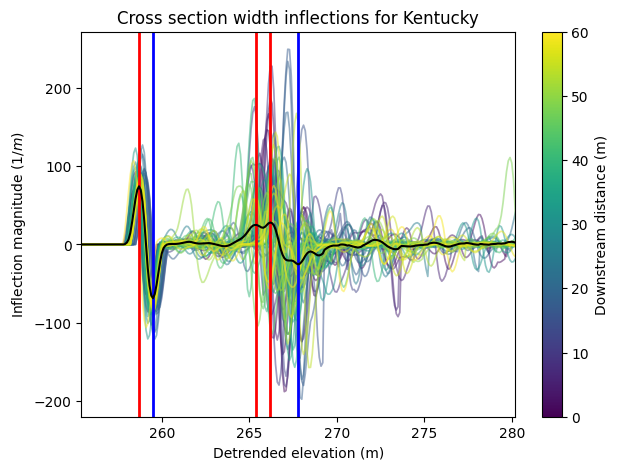

In [7]:
# Plotting functions
print('Generating visualizations...')
plot_longitudinal_profile(reach_name)
plot_bankfull_increments(reach_name, d_interval)
transect_plot(cross_sections, dem_fp, sampling_interval, d_interval, reach_name)
plot_inflections(d_interval, reach_name)

Finally, a spatial function is called from the ```spatial_analysis.py``` file to generate points where the INFLECT elevations intersect each cross-section. If an INFLECT elevation intersects the cross-section multiple times, only the intersections closest to the centerline are retained. Positive and negative inflections are stored in separate shapefiles as multipoint objects. If there are multiple inflections identified, a particular elevation can be specified in the spatial analysis function. This spatial output can be highly valuable when interpreting the results from INFLECT. 

In [8]:
# Spatial analysis
create_bankfull_pts(cross_sections, dem_fp, thalweg, d_interval, spatial_plot_interval, reach_name)

mapping positive inflections
mapping negative inflections
